<a href="https://colab.research.google.com/github/heathcliffaindcrad/PROJECT-OPENGL/blob/UTAMA/AI_Workflow_Toko_Kai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TUGAS 1 : LATIHAN WORKFLOW A

In [ ]:
import pandas as pd

# Buat data penjualan toko
data = {
    "Tanggal": ["2025-02-01", "2025-02-01", "2025-02-02", "2025-02-01", "2025-02-03", "2025-02-03"],
    "Produk" :["Minyak Goreng", "Beras", "Gula", "Tepung", "Mie Instan", "Susu"],
    "Jumlah Terjual" : [10, 5, 7, 3, 12, 8],
    "Stok": [20, 15, 8, 12, 25, 10],
    "Harga Satuan" : [15000, 12000, 13000, 11000, 3000, 18000],
}

df = pd.DataFrame(data)

df.to_csv("data_penjualan.csv", index=False)

print("File CSV berhasil dibuat dan disimpan sebagai 'data_penjualan.csv' !'")

File CSV berhasil dibuat dan disimpan sebagai 'data_penjualan.csv' !'


In [ ]:
# Membaca file CSV
dt = pd.read_csv("data_penjualan.csv")

print(dt.head())


      Tanggal         Produk  Jumlah Terjual  Stok  Harga Satuan
0  2025-02-01  Minyak Goreng              10    20         15000
1  2025-02-01          Beras               5    15         12000
2  2025-02-02           Gula               7     8         13000
3  2025-02-01         Tepung               3    12         11000
4  2025-02-03     Mie Instan              12    25          3000


In [ ]:
# Cek apakah ada data yang kosong
print(df.isnull().sum())

# Konversi kolom "Tanggal" ke format datetime
df["Tanggal"] = pd.to_datetime(df["Tanggal"])

# Tambahkan kolo "Total Penjualan"
df["Total Penjualan"] = df["Jumlah Terjual"] * df["Harga Satuan"]

df["Keuntugan"] = df["Total Penjualan"] - (df["Jumlah Terjual"] * 10000)

# Menampilkan hasil transformasi
print(df.head())

Tanggal            0
Produk             0
Jumlah Terjual     0
Stok               0
Harga Satuan       0
Total Penjualan    0
Keuntugan          0
dtype: int64
     Tanggal         Produk  Jumlah Terjual  Stok  Harga Satuan  \
0 2025-02-01  Minyak Goreng              10    20         15000   
1 2025-02-01          Beras               5    15         12000   
2 2025-02-02           Gula               7     8         13000   
3 2025-02-01         Tepung               3    12         11000   
4 2025-02-03     Mie Instan              12    25          3000   

   Total Penjualan  Keuntugan  
0           150000      50000  
1            60000      10000  
2            91000      21000  
3            33000       3000  
4            36000     -84000  


In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Pilih fitur X dan target Y
X = df[["Jumlah Terjual", "Stok"]]
y = (df["Stok"] < 5).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Akurasi Model :"), accuracy_score(y_test, y_pred)

dt

Akurasi Model :


,Tanggal,Produk,Jumlah Terjual,Stok,Harga Satuan
0,2025-02-01,Minyak Goreng,10,20,15000
1,2025-02-01,Beras,5,15,12000
2,2025-02-02,Gula,7,8,13000
3,2025-02-01,Tepung,3,12,11000
4,2025-02-03,Mie Instan,12,25,3000
5,2025-02-03,Susu,8,10,18000


In [ ]:
produk_baru = [[8, 3]]
predict = model.predict(produk_baru)

if predict[0] == 1:
  print("Produk perlu di-restock!")
else:
  print("Stok masih cukup.")

Stok masih cukup.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


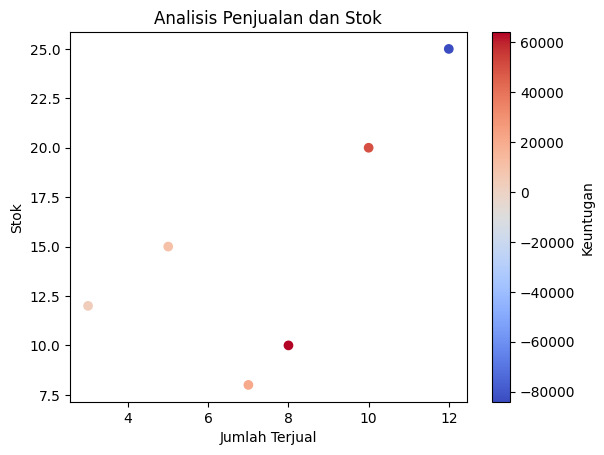

,Tanggal,Produk,Jumlah Terjual,Stok,Harga Satuan
0,2025-02-01,Minyak Goreng,10,20,15000
1,2025-02-01,Beras,5,15,12000
2,2025-02-02,Gula,7,8,13000
3,2025-02-01,Tepung,3,12,11000
4,2025-02-03,Mie Instan,12,25,3000
5,2025-02-03,Susu,8,10,18000


In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df["Jumlah Terjual"], df["Stok"], c=df["Keuntugan"], cmap="coolwarm")
plt.xlabel("Jumlah Terjual")
plt.ylabel("Stok")
plt.title("Analisis Penjualan dan Stok")
plt.colorbar(label = "Keuntugan")
plt.show()

dt

In [ ]:
print(df.Keuntugan)

0    50000
1    10000
2    21000
3     3000
4   -84000
5    64000
Name: Keuntugan, dtype: int64
